Ahmad Yudistira ramdhany - 0110224005


  **LaporanPraktikum 13 – Klasifikasi Citra Angka Tulisan Tangan Menggunakan Multi-Layer Perceptron (MLP) pada Dataset MNIST)**

1. Menghubungkan Colab ke Google Drive

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
path = "/content/drive/MyDrive/Machine_Learning/Praktikum13/data"

2. Import Library

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets
import torchvision.transforms as transforms


3. Load Persiapan Dataset MNIST

In [33]:
num_workers = 0
batch_size = 20

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=batch_size,
    num_workers=num_workers
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    num_workers=num_workers
)


4. Visualisasi Data

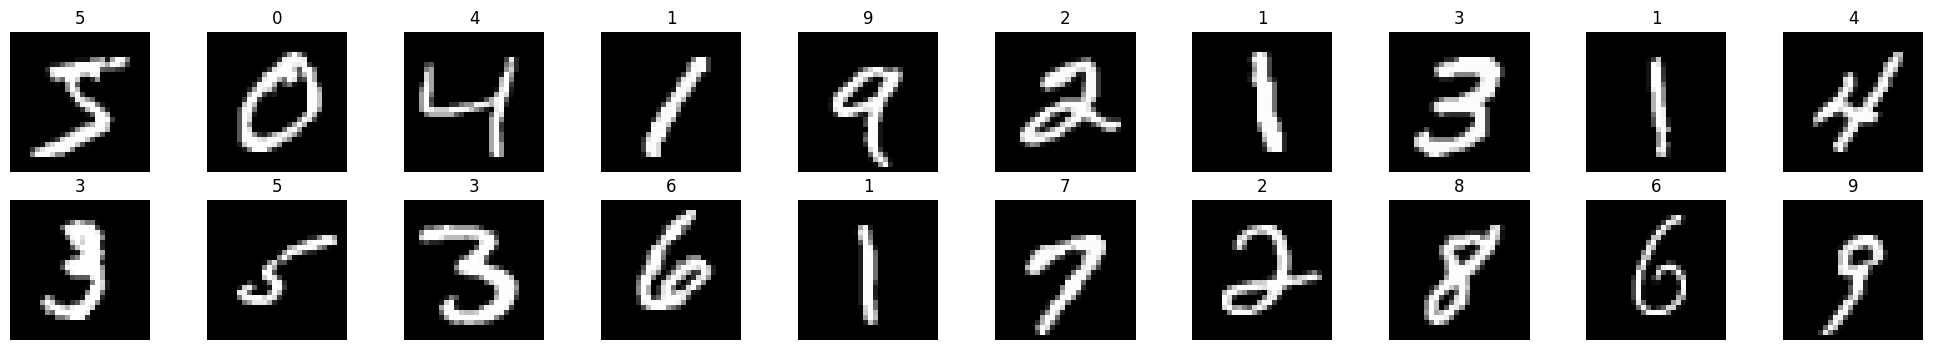

In [34]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1)
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(str(labels[idx].item()))
    ax.axis('off')


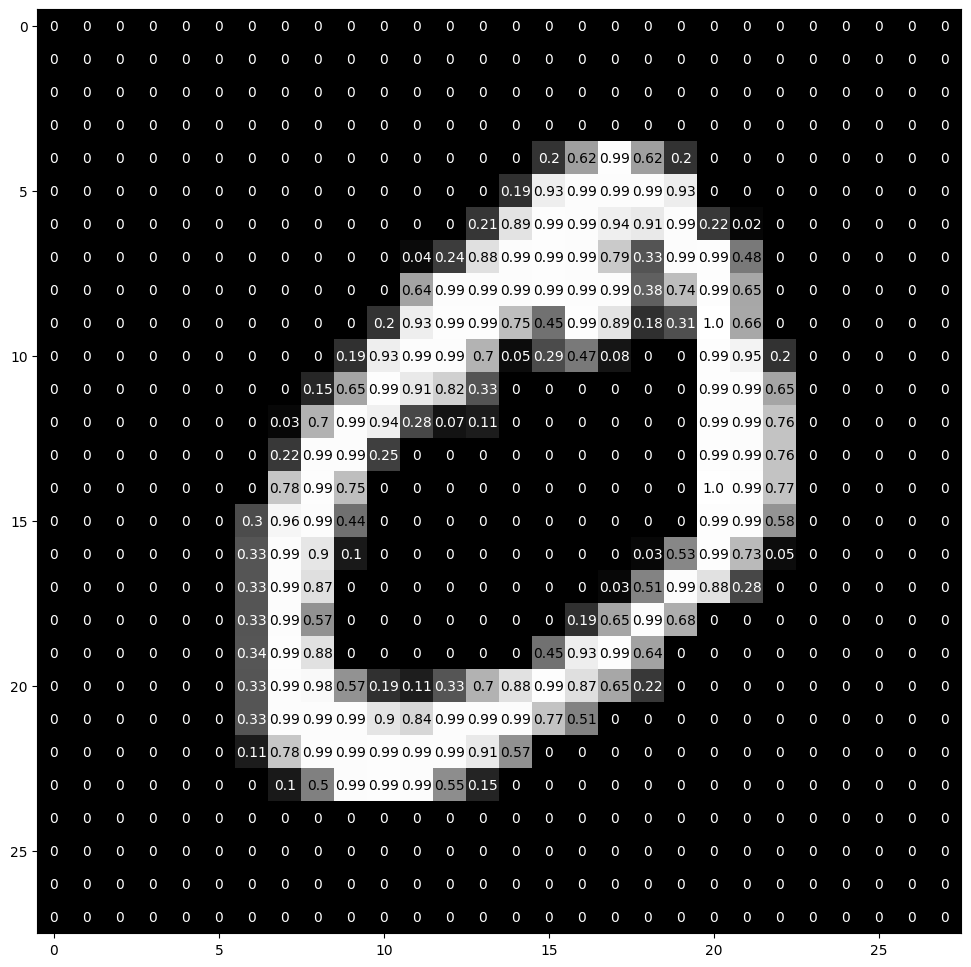

In [35]:
# Visualisasi Data Dalam 1 Gambar

img = np.squeeze(images[1])

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

5. Definisi Arsitektur Jaringan Saraf (MLP)

In [36]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

model = Net()
print(model)


Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


6. Fungsi Loss dan Optimizer

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


7. Proses Training Model

In [38]:
n_epochs = 30
model.train()

for epoch in range(n_epochs):
    train_loss = 0.0

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

    train_loss /= len(train_loader.dataset)
    print(f"Epoch: {epoch+1} \tTraining Loss: {train_loss:.6f}")


Epoch: 1 	Training Loss: 0.820078
Epoch: 2 	Training Loss: 0.325891
Epoch: 3 	Training Loss: 0.254352
Epoch: 4 	Training Loss: 0.207196
Epoch: 5 	Training Loss: 0.174956
Epoch: 6 	Training Loss: 0.150945
Epoch: 7 	Training Loss: 0.133050
Epoch: 8 	Training Loss: 0.117480
Epoch: 9 	Training Loss: 0.105913
Epoch: 10 	Training Loss: 0.095712
Epoch: 11 	Training Loss: 0.087000
Epoch: 12 	Training Loss: 0.080529
Epoch: 13 	Training Loss: 0.074164
Epoch: 14 	Training Loss: 0.068559
Epoch: 15 	Training Loss: 0.064452
Epoch: 16 	Training Loss: 0.059675
Epoch: 17 	Training Loss: 0.055946
Epoch: 18 	Training Loss: 0.053026
Epoch: 19 	Training Loss: 0.048932
Epoch: 20 	Training Loss: 0.046973
Epoch: 21 	Training Loss: 0.044344
Epoch: 22 	Training Loss: 0.040946
Epoch: 23 	Training Loss: 0.038473
Epoch: 24 	Training Loss: 0.036630
Epoch: 25 	Training Loss: 0.034896
Epoch: 26 	Training Loss: 0.033145
Epoch: 27 	Training Loss: 0.031458
Epoch: 28 	Training Loss: 0.029062
Epoch: 29 	Training Loss: 0.0

8. Evaluasi Model pada Data Uji

In [39]:
test_loss = 0.0
class_correct = list(0. for _ in range(10))
class_total = list(0. for _ in range(10))

model.eval()

for data, target in test_loader:
    output = model(data)
    loss = criterion(output, target)
    test_loss += loss.item() * data.size(0)

    _, pred = torch.max(output, 1)
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))

    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.6f}\n")

for i in range(10):
    print(f"Akurasi Kelas {i}: {100*class_correct[i]/class_total[i]:.0f}% "
          f"({int(class_correct[i])}/{int(class_total[i])})")

print(f"\nAkurasi Total: "
      f"{100*np.sum(class_correct)/np.sum(class_total):.0f}% "
      f"({int(np.sum(class_correct))}/{int(np.sum(class_total))})")


Test Loss: 0.055995

Akurasi Kelas 0: 99% (972/980)
Akurasi Kelas 1: 99% (1127/1135)
Akurasi Kelas 2: 98% (1015/1032)
Akurasi Kelas 3: 98% (992/1010)
Akurasi Kelas 4: 98% (965/982)
Akurasi Kelas 5: 98% (877/892)
Akurasi Kelas 6: 98% (940/958)
Akurasi Kelas 7: 98% (1003/1028)
Akurasi Kelas 8: 97% (943/974)
Akurasi Kelas 9: 98% (987/1009)

Akurasi Total: 98% (9821/10000)


9. Visualisasi Hasil Prediksi

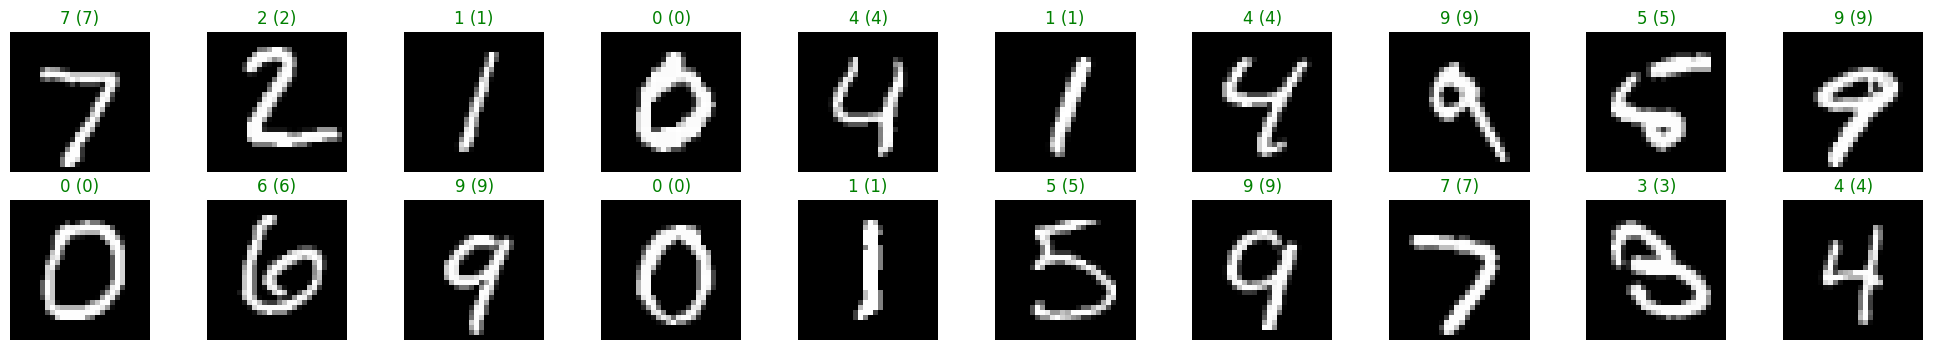

In [41]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

output = model(images)
_, preds = torch.max(output, 1)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1)
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(f"{preds[idx].item()} ({labels[idx].item()})",
                 color="green" if preds[idx]==labels[idx] else "red")
    ax.axis('off')


10. Kesimpulan

Berdasarkan hasil praktikum Machine Learning – Neural Network (Artificial Neural Network) yang telah dilakukan menggunakan dataset MNIST, dapat disimpulkan beberapa hal penting sebagai berikut:


*   Dataset MNIST yang berisi citra angka tulisan tangan berhasil dimuat, divisualisasikan, dan dipahami strukturnya melalui tahap eksplorasi data, termasuk visualisasi batch data dan detail nilai pixel pada satu citra.

*   Model Artificial Neural Network dengan arsitektur Multi-Layer Perceptron (MLP) yang terdiri dari dua hidden layer dan fungsi aktivasi ReLU berhasil dibangun dan dilatih menggunakan data training.

*   Proses training menunjukkan penurunan nilai loss secara bertahap pada setiap epoch, yang menandakan bahwa model mampu mempelajari pola dari data dengan baik.

*   Evaluasi model pada data uji menunjukkan tingkat akurasi sekitar 98%, baik secara keseluruhan maupun pada masing-masing kelas angka, sehingga dapat disimpulkan bahwa model memiliki kemampuan generalisasi yang baik.

*   Visualisasi hasil prediksi memperlihatkan bahwa sebagian besar citra angka dapat diklasifikasikan dengan benar, yang ditandai dengan kesesuaian antara label prediksi dan label asli.


*   Secara keseluruhan, hasil praktikum ini membuktikan bahwa metode Artificial Neural Network khususnya Multi-Layer Perceptron cukup efektif untuk menyelesaikan permasalahan klasifikasi citra sederhana seperti dataset MNIST.





